## Data loading

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [24]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import stream as st
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
def load_anndata(file_count, file_barcode=None, file_gene=None, workdir=None):
    # Be careful, the countings are transposed.
    adata = st.read(file_name=file_count, workdir=workdir)
    if file_barcode is not None:
        adata.var = pd.read_csv(_file_barcode, delimiter="\t").set_index("barcode")
    if file_gene is not None:
        adata.obs = pd.read_csv(_file_gene, delimiter="\t").set_index("gene_name")
    return adata

In [3]:
st.set_figure_params(dpi=80,style='white',figsize=[5.4,4.8], rc={'image.cmap': 'viridis'})

epg_alpha=float(0.01)
epg_mu=float(0.05)
epg_lambda=float(0.05)

In [68]:
_inpath = Path("/leukemias/data/results/preprocess").resolve()
_file_count = Path(f"{_inpath}/X.csv").resolve()
_file_barcode = Path(f"{_inpath}/obs.csv").resolve()
_file_gene = Path(f"{_inpath}/var.csv").resolve()
_outpath = Path("/leukemias/data/results/stream_results").resolve()
_outfile = Path(f"{_outpath}/stream_metadata.csv")

if not _outpath.exists():
    _outpath.mkdir()

In [55]:
adata = load_anndata(file_count=_file_count, file_barcode=_file_barcode, file_gene=_file_gene, workdir=_outpath)

Saving results in: /leukemias/data/results/stream_results


In [57]:
adata

AnnData object with n_obs × n_vars = 2763 × 13115 
    obs: 'transcript_id', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    var: 'label', 'n_genes_by_counts', 'total_counts', 'n_genes'
    uns: 'workdir'

## Highly Variable Gene Selection

### Feature selection

656 variable genes are selected


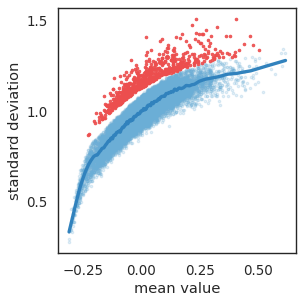

In [59]:
st.select_variable_genes(adata,loess_frac=0.02)

using all the features ...
15 PCs are selected


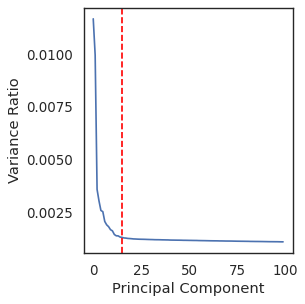

In [60]:
st.select_top_principal_components(adata, first_pc=True, n_pc=15)

In [61]:
st.dimension_reduction(adata, method="mlle", feature="top_pcs", n_components=4, n_neighbors=50, n_jobs=5)
# st.dimension_reduction(adata, method='umap', feature='top_pcs', n_components=3, n_neighbors=15, n_jobs=6)

feature top_pcs is being used ...
5 cpus are being used ...


In [62]:
st.seed_elastic_principal_graph(adata, n_clusters=10)

Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 7


In [63]:
st.elastic_principal_graph(adata=adata, epg_alpha=epg_alpha, epg_mu=epg_mu, epg_lambda=epg_lambda)
st.extend_elastic_principal_graph(adata, epg_ext_mode='WeigthedCentroid', epg_ext_par=0.8)

Learning elastic principal graph...
[1]
 "Constructing tree 1 of 1 / Subset 1 of 1"


[1]
 "Computing EPG with 50 nodes on 1413 points and 4 dimensions"


[1]
 "Using a single core"


Nodes = 
10
 
11
 
12
 
13
 
14
 
15
 
16
 
17
 
18
 
19
 
20
 
21
 
22
 
23
 
24
 
25
 
26
 
27
 
28
 
29
 
30
 
31
 
32
 
33
 
34
 
35
 
36
 
37
 
38
 
39
 
40
 
41
 
42
 
43
 
44
 
45
 
46
 
47
 
48
 
49
 


BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD

3||50
	
0.00105
	
50
	
49
	
42
	
3
	
0
	
0
	
0.0005656
	
0.000555
	
0.8003
	
0.8041
	
0.0004664
	
1.841e-05
	
0.0009206
	
0.04603
	
0


13.921 sec elapsed

[[1]]



Number of branches after learning elastic principal graph: 7
Extending leaves with additional nodes ...
Number of branches after extending leaves: 7


In [64]:
adata

AnnData object with n_obs × n_vars = 1413 × 13112 
    obs: 'transcript_id', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'n_genes', 'pct_genes', 'pct_mt', 'kmeans', 'node', 'branch_id', 'branch_id_alias', 'branch_lam', 'branch_dist', 'S0_pseudotime', 'S3_pseudotime', 'S2_pseudotime', 'S7_pseudotime', 'S5_pseudotime', 'S4_pseudotime', 'S6_pseudotime', 'S1_pseudotime'
    var: 'label', 'n_genes_by_counts', 'total_counts', 'n_genes', 'n_counts', 'n_cells', 'pct_cells'
    uns: 'workdir', 'assay', 'var_genes', 'pca_variance_ratio', 'top_pcs', 'params', 'trans_mlle', 'epg', 'flat_tree', 'seed_epg', 'seed_flat_tree', 'ori_epg', 'epg_obj', 'ori_epg_obj'
    obsm: 'var_genes', 'pca', 'top_pcs', 'X_mlle', 'X_dr'

In [65]:
st.plot_stream(adata, root="S1", color=['S1_pseudotime'], log_scale=True, factor_zoomin=200, save_fig=True, fig_path=_outpath, fig_format="png")

In [69]:
adata.obs.to_csv(_outfile)